# E11: Standard OTDD on real data

**Started:** February 10, 2026

**Last updated:** February 16, 2026

**Research questions:** Does OTDD improve class matching accuracy and subclass accuracy compared to base entropic GW?

**Hypothesis:** OTDD will get class matching accuracy above 90%+ for couplings between individuals, 80% between humans, and 50% between species, all higher than base entropic GW.

**Conclusion:** OTDD better than base GW, but still has class-level mismatch, resulting in . OTDD alone is insufficient for accomplishing class accuracy with no anchoring. Sublabel accuracy is low when there are class-level mismatches.

**Potential Next Steps:** See if Perturb-OT has better sublabel accuracy than OTDD.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy.spatial.distance import cdist
from scipy import sparse
import ot
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from __future__ import annotations
from typing import Tuple, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              plot_ot_transport_by_celltype
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims
import torch
from torch.utils.data import TensorDataset, DataLoader
from otdd.pytorch.datasets import load_torchvision_data
from otdd.pytorch.distance import DatasetDistance, IncomparableDatasetDistance
%matplotlib inline

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ot.gpu not found - coupling computation will be in cpu


### OTDD tutorial 

In [3]:
loaders_src = load_torchvision_data('MNIST', valid_size=0, resize = 28, maxsize=2000)[0]
loaders_tgt = load_torchvision_data('USPS',  valid_size=0, resize = 28, maxsize=2000)[0]

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.43MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]


Fold Sizes: 2000/10000 (train/test)


100%|██████████| 6.58M/6.58M [00:01<00:00, 4.15MB/s]
100%|██████████| 1.83M/1.83M [00:01<00:00, 1.76MB/s]


Fold Sizes: 2000/2007 (train/test)


In [11]:
dist = DatasetDistance(loaders_src['train'], loaders_tgt['train'],
                       inner_ot_method = 'exact',
                       debiased_loss = True,
                       p = 2, entreg = 1e-1,
                       device='cpu')

In [12]:
d = dist.distance(maxsamples = 1000)
print(f'OTDD(src,tgt)={d}')

OTDD(src,tgt)=932.7022094726562


In [2]:
def make_loader_from_numpy(xs: np.ndarray, ys: pd.Series, batch_size: int = 128, shuffle: bool = True, num_workers: int = 0):
    X = torch.from_numpy(xs).float()
    # convert labels to integer indices if they are strings
    if pd.api.types.is_integer_dtype(ys.dtype) or pd.api.types.is_float_dtype(ys.dtype):
        y_tensor = torch.from_numpy(ys.to_numpy()).long()
    else:
        # map unique labels -> ints
        mapping = {lbl: i for i, lbl in enumerate(pd.unique(ys))}
        y_tensor = torch.tensor([mapping[v] for v in ys.to_numpy()], dtype=torch.long)
    ds = TensorDataset(X, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

### Load in Tabula data

In [2]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [3]:
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
mouse_adatas = top_n_organisms_from_species(mouse_dir, 2, 'mouse')

In [4]:
human1a, human1b = split_adata_by_celltype_tissue(human_adatas[0], cell_number=200, min_per_cell_type=5)

In [5]:
num_cells = human1a.obsm['X_pca'].shape[0]

In [6]:
sc.tl.pca(human1a, n_comps=50, svd_solver="arpack")
sc.tl.pca(human1b, n_comps=50, svd_solver="arpack")

In [7]:
ct_vc = human1a.obs['shared_cell_type'].value_counts()
ct_keep = ct_vc[ct_vc>=2].index.tolist()

In [8]:
human1a = human1a[human1a.obs['shared_cell_type'].isin(ct_keep)]

In [9]:
human1b = human1b[human1b.obs['shared_cell_type'].isin(ct_keep)]

In [10]:
human1a_X = human1a.obsm['X_pca']
human1b_X = human1b.obsm['X_pca']
human1a_labels = human1a.obs['shared_cell_type'].tolist()
human1b_labels = human1b.obs['shared_cell_type'].tolist()

In [113]:
human1a_loader = make_loader_from_numpy(human1a_X.copy(), pd.Series(human1a_labels))

In [114]:
human1b_loader = make_loader_from_numpy(human1b_X.copy(), pd.Series(human1b_labels))

In [115]:
dist = IncomparableDatasetDistance(human1a_loader, human1b_loader,
                       inner_ot_method = 'exact',
                       debiased_loss = False, 
                       p = 2, entreg = 0.01,
                       device='cpu')

In [116]:
pi = dist.compute_coupling(entreg=0.01, λ_y=0.0)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


In [117]:
pi.shape

(195, 195)

In [118]:
np.max(pi)

np.float64(0.005118073583793275)

In [30]:
plot_ot_transport_by_celltype(pi, human1a_labels, human1b_labels)

NameError: name 'pi' is not defined

In [122]:
compute_mapping_acc(pi, human1a_labels, human1b_labels)

0.10256410256410256

In [36]:
pi

array([[2.72395628e-05, 2.53965423e-05, 2.51259652e-05, ...,
        2.46641399e-05, 2.52434791e-05, 2.59503427e-05],
       [2.97107916e-05, 2.76750635e-05, 2.61703958e-05, ...,
        2.76114039e-05, 2.83614958e-05, 2.67757722e-05],
       [2.50750453e-05, 2.70049271e-05, 2.98390022e-05, ...,
        2.70627681e-05, 2.54385338e-05, 2.35202965e-05],
       ...,
       [2.58324706e-05, 2.74125815e-05, 2.68423272e-05, ...,
        2.59118173e-05, 2.81498853e-05, 2.48455976e-05],
       [2.67589368e-05, 2.97091874e-05, 2.62449537e-05, ...,
        2.79929839e-05, 2.99891855e-05, 2.47152146e-05],
       [2.88441498e-05, 2.74674256e-05, 2.69369476e-05, ...,
        2.91895128e-05, 2.73010258e-05, 2.86880380e-05]], shape=(195, 195))

### My own implementation of OTDD

In [5]:
def uot_w2_cost(
    X: np.ndarray,
    Y: np.ndarray,
    a: np.ndarray | None = None,
    b: np.ndarray | None = None,
    reg: float = 0.05,     # entropic regularization (epsilon)
    reg_m: float = 10.0,   # marginal relaxation strength (rho)
    metric: str = "euclidean",
    squared: bool = True,
    **sinkhorn_kwargs,
) -> float:
    """
    Unbalanced entropic OT cost with squared Euclidean ground cost (2-Wasserstein style).

    X: (n, d), Y: (m, d)
    a, b: optional nonnegative weights (do NOT need to sum to 1 for unbalanced OT)
    reg: entropic regularization epsilon
    reg_m: marginal relaxation (larger -> closer to balanced OT)
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    n, m = X.shape[0], Y.shape[0]

    # weights (can be unnormalized for unbalanced OT)
    if a is None:
        a = np.ones(n, dtype=np.float64) / n
    else:
        a = np.asarray(a, dtype=np.float64)
    if b is None:
        b = np.ones(m, dtype=np.float64) / m
    else:
        b = np.asarray(b, dtype=np.float64)

    # cost matrix
    M = ot.dist(X, Y, metric=metric)  # pairwise distances
    if squared:
        M = M ** 2

    # optional normalization for numerical stability
    M = M / (M.max() + 1e-12)

    # sinkhorn_unbalanced2 returns the OT *cost*
    cost = ot.unbalanced.sinkhorn_unbalanced2(
        a, b, M, reg=reg, reg_m=reg_m, **sinkhorn_kwargs
    )
    return float(cost)


In [6]:
def pairwise_uot_w2_by_label(
    X: np.ndarray,
    labels,
    *,
    reg: float = 0.05,
    reg_m: float = 10.0,
    metric: str = "euclidean",
    squared: bool = True,
    normalize_cost: bool = True,
    min_count: int = 1,
    label_order=None,
    **uot_kwargs,
) -> pd.DataFrame:
    """
    Compute a label-by-label matrix of (regularized) unbalanced 2-Wasserstein costs
    between point subclouds using `uot_w2_cost`.

    Parameters
    ----------
    X : (n, d) numpy array
        Points (cells).
    labels : array-like length n
        Population labels per row of X.
    reg, reg_m, metric, squared :
        Passed through to `uot_w2_cost`.
    normalize_cost : bool
        If True, divides each pairwise cost by max(C) inside uot_w2_cost (recommended for stability).
        (Only used if your uot_w2_cost supports/uses it; otherwise ignored via **uot_kwargs.)
    min_count : int
        Only include labels with at least this many points.
    label_order : optional list
        Order of labels in the output matrix. If None, uses sorted unique labels after filtering.
    **uot_kwargs :
        Any extra kwargs forwarded to `uot_w2_cost` (e.g., numItermax, stopThr).

    Returns
    -------
    pd.DataFrame
        Square matrix (K x K) of costs with index/columns = labels.
        Symmetric if metric/cost is symmetric (it is in this setting).
    """
    X = np.asarray(X, dtype=np.float64)
    lab = pd.Series(labels).reset_index(drop=True)

    if len(lab) != X.shape[0]:
        raise ValueError(f"labels length {len(lab)} != X rows {X.shape[0]}")

    # filter labels by min_count
    vc = lab.value_counts()
    keep = vc[vc >= min_count].index

    if label_order is None:
        labs = sorted(keep.tolist())
    else:
        labs = [l for l in label_order if l in set(keep)]

    if len(labs) == 0:
        return pd.DataFrame(dtype=float)

    # pre-slice indices for speed
    idx_by_lab = {l: lab[lab == l].index.to_numpy() for l in labs}

    K = len(labs)
    D = np.full((K, K), np.nan, dtype=float)

    for i, li in enumerate(labs):
        Xi = X[idx_by_lab[li]]
        if Xi.shape[0] == 0:
            continue
        for j in range(i, K):
            lj = labs[j]
            Xj = X[idx_by_lab[lj]]
            if Xj.shape[0] == 0:
                continue

            # uot_w2_cost is assumed to exist in your namespace (from earlier)
            d = uot_w2_cost(
                Xi,
                Xj,
                reg=reg,
                reg_m=reg_m,
                metric=metric,
                squared=squared,
                **uot_kwargs,
            )
            D[i, j] = d
            D[j, i] = d

    return pd.DataFrame(D, index=labs, columns=labs)

In [7]:
label_dist_df = pairwise_uot_w2_by_label(human1a_X, human1a_labels)

NameError: name 'human1a_X' is not defined

In [ ]:
label_dist_df

<Axes: >

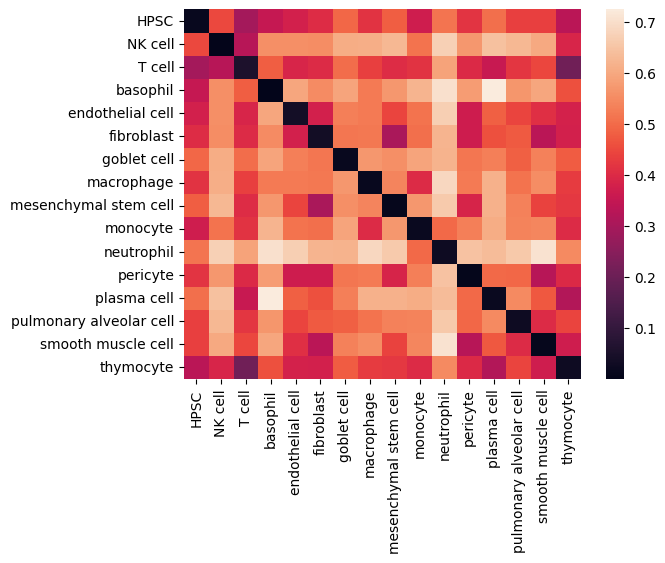

In [17]:
sns.heatmap(label_dist_df)

In [25]:
def otdd_distance_matrix(
    D: pd.DataFrame,
    M: np.ndarray,   # (n, d) coordinates/features
    L,
    p: float = 2.0,
    feature_metric: str = "euclidean",
    reg_y: float = 1.0,                 # NEW: weight on label term
    label_distance_is_powered: bool = True,  # True if D stores W_p^p (e.g. W2^2)
) -> np.ndarray:
    """
    Build OTDD-style augmented distance matrix over points from coordinates.

    d_Z((x,y),(x',y')) =
        ( d_X(x,x')^p + reg_y * W_p^p(alpha_y, alpha_y') )^(1/p)

    Parameters
    ----------
    D : pd.DataFrame (K x K)
        Label-label distances. Typically W_p^p (e.g. W2^2).
    M : np.ndarray (n, d)
        Point coordinates/features.
    L : array-like length n
        Label for each point.
    p : float
        Power p used in the OTDD-style augmentation.
    feature_metric : str
        Metric for d_X computed via scipy.spatial.distance.cdist.
    reg_y : float
        Weight on the label-distance term W_p^p.
        - reg_y = 0 ignores labels
        - larger reg_y emphasizes label separation
    label_distance_is_powered : bool
        If True, D entries are W_p^p. If False, D entries are W_p and will be raised to p.

    Returns
    -------
    Z : np.ndarray (n, n)
        Augmented distance matrix over points.
    """
    M = np.asarray(M, dtype=float)
    labels = pd.Series(L).reset_index(drop=True)

    n = labels.shape[0]
    if M.ndim != 2 or M.shape[0] != n:
        raise ValueError(f"M must be shape (n,d) with n=len(L)={n}; got {M.shape}")

    if not isinstance(D, pd.DataFrame):
        raise TypeError("D must be a pandas DataFrame with index/columns as label names")

    missing = set(labels.unique()) - set(D.index)
    if missing:
        raise KeyError(f"Labels missing from D: {sorted(missing)}")

    if reg_y < 0:
        raise ValueError("reg_y must be >= 0")

    # 1) feature distances d_X from coordinates
    dX = cdist(M, M, metric=feature_metric)  # (n,n)

    # 2) label-label distances expanded to point-pair matrix
    Dv = D.to_numpy(dtype=float)
    lab_to_idx = {lab: i for i, lab in enumerate(D.index)}
    codes = labels.map(lab_to_idx).to_numpy(dtype=int)
    dY = Dv[codes[:, None], codes[None, :]]  # (n,n)

    if not label_distance_is_powered:
        dY = dY ** p  # convert W_p -> W_p^p

    # 3) combine with weighting
    return (np.power(dX, p) + reg_y * dY) ** (1.0 / p)


In [185]:
otdd_dists1a = otdd_distance_matrix(label_dist_df, human1a_X, human1a_labels, reg_y=100000)

[[12.3308918  29.89064686 35.75964252 ... 73.63328128 77.02876949
  74.2234919 ]
 [29.89064686 12.3308918  37.39472612 ... 78.28380476 82.32738639
  79.12367875]
 [35.75964252 37.39472612 12.3308918  ... 67.91790551 69.74867977
  67.50948909]
 ...
 [73.63328128 78.28380476 67.91790551 ... 16.31031874 25.51844497
  19.04183153]
 [77.02876949 82.32738639 69.74867977 ... 25.51844497 16.31031874
  24.80859094]
 [74.2234919  79.12367875 67.50948909 ... 19.04183153 24.80859094
  16.31031874]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

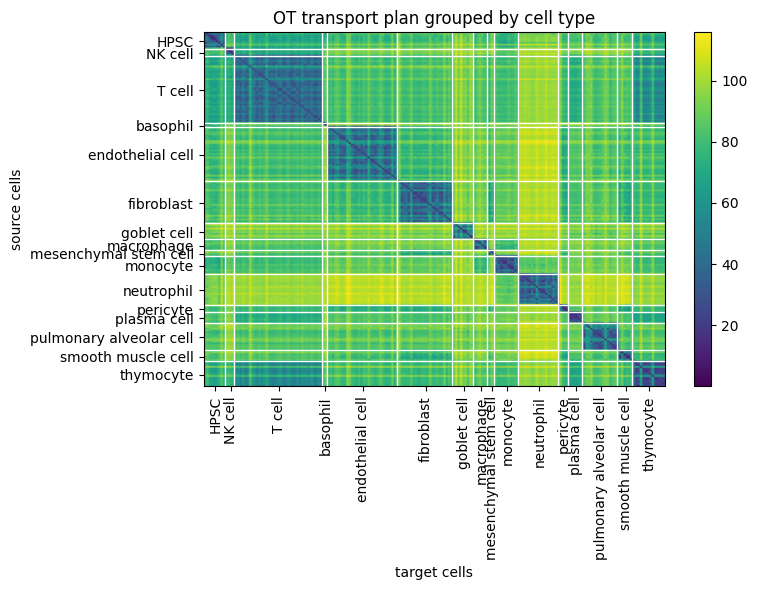

In [186]:
plot_ot_transport_by_celltype(otdd_dists1, human1a_labels, human1b_labels)

In [180]:
label_dist_df1b = pairwise_uot_w2_by_label(human1b_X, human1b_labels)

In [187]:
otdd_dists1b = otdd_distance_matrix(label_dist_df1b, human1b_X, human1b_labels, reg_y=100000)

In [33]:
def run_gw_otdd(C1, C2, epsilon=0.1):
    C1 /= C1.max()
    C2 /= C2.max()

    n_samples = C1.shape[0]

    p = ot.unif(n_samples)
    q = ot.unif(n_samples)

    # Proximal Point algorithm with Kullback-Leibler as proximal operator
    gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=epsilon, solver="PPA", log=True)
    
    return gw

In [189]:
gw_otdd = run_gw_otdd(otdd_dists1a, otdd_dists1b, epsilon=0.01)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [190]:
compute_mapping_acc(gw_otdd, human1a_labels, human1b_labels)

0.958974358974359

In [73]:
plot_ot_transport_by_celltype(gw_otdd, human1a_labels, human1b_labels)

NameError: name 'gw_otdd' is not defined

### Looking at sublabel accuracy

In [206]:
human1a[human1a.obs['shared_cell_type']=='monocyte'].obs['cell_type'].value_counts()

cell_type
classical monocyte        4
intermediate monocyte     4
monocyte                  1
non-classical monocyte    1
Name: count, dtype: int64

In [39]:
def cell_subtype_codes(
    adata,
    cell_subtypes,
    cell_type_key="cell_type",
):
    """
    Return a list of subtype codes aligned with adata.obs.index:
      - 0 if cell_type not in cell_subtypes
      - i+1 if cell_type == cell_subtypes[i]
    """
    mapping = {ct: i + 1 for i, ct in enumerate(cell_subtypes)}
    return (
        adata.obs[cell_type_key]
        .map(mapping)
        .fillna(0)
        .astype(int)
        .to_list()
    )

In [228]:
monocyte_cst = human1a[human1a.obs['shared_cell_type']=='monocyte'].obs['cell_type'].value_counts().index.tolist()

In [229]:
human1a_cst = cell_subtype_codes(human1a, monocyte_cst)

In [230]:
human1b_cst = cell_subtype_codes(human1b, monocyte_cst)

In [235]:
sublabel_match_rate_from_gw(gw_otdd, human1a_labels, human1b_labels, human1a_cst, human1b_cst)

0.9

90% cell subtype accuracy for monocytes off the bat! Remove the general 'monocyte' one to see if it improves.

### Comparing two humans

In [8]:
num_cells = 500

In [9]:
human1, human2 =  match_cells_by_celltype_tissue(human_adatas[0], human_adatas[1], cell_number=num_cells)

In [10]:
human1 = human1[human1.obs['cell_type']!='monocyte']  # remove generic 'monocyte' cell type
human2 = human2[human2.obs['cell_type']!='monocyte']

In [11]:
human1_X = human1.obsm['X_pca']
human2_X = human2.obsm['X_pca']

In [12]:
human1_labels = human1.obs['shared_cell_type'].tolist()
human2_labels = human2.obs['shared_cell_type'].tolist()

In [13]:
label_dist_df1 = pairwise_uot_w2_by_label(human1_X, human1_labels)

In [14]:
label_dist_df2 = pairwise_uot_w2_by_label(human2_X, human2_labels)

In [74]:
otdd_dists1 = otdd_distance_matrix(label_dist_df1, human1_X, human1_labels, reg_y=5000)

In [75]:
otdd_dists2 = otdd_distance_matrix(label_dist_df2, human2_X, human2_labels, reg_y=5000)

[[12.12418641 15.1702103  15.84222396 ... 44.51283079 45.07733465
  46.43520089]
 [15.1702103  12.12418641 14.95158657 ... 44.41541458 44.96115936
  46.28187042]
 [15.84222396 14.95158657 12.12418641 ... 45.01725872 45.13186914
  45.91229535]
 ...
 [44.51283079 44.41541458 45.01725872 ... 15.32320716 20.7326855
  22.41984313]
 [45.07733465 44.96115936 45.13186914 ... 20.7326855  15.32320716
  21.85965821]
 [46.43520089 46.28187042 45.91229535 ... 22.41984313 21.85965821
  15.32320716]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

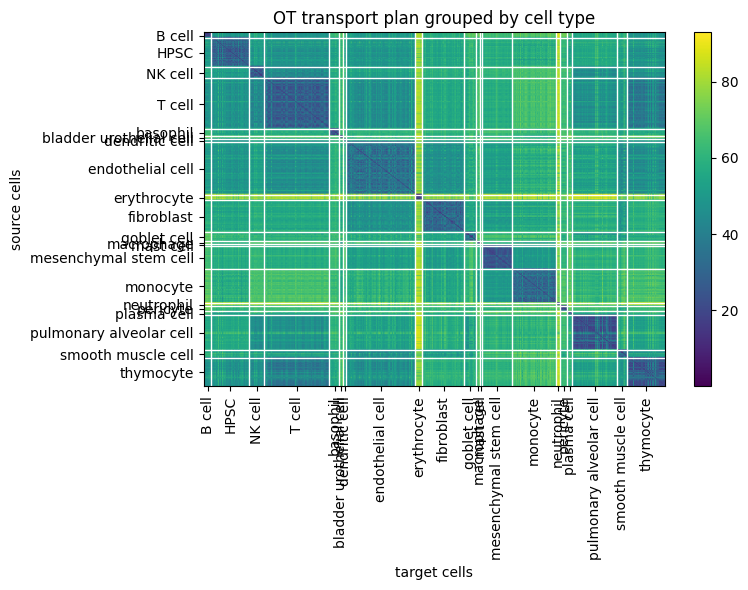

In [76]:
plot_ot_transport_by_celltype(otdd_dists1, human1_labels, human2_labels)

In [77]:
gw_otdd_twohumans = run_gw_otdd(otdd_dists1, otdd_dists2, epsilon=0.01)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


[[2.04573996e-011 6.36059597e-004 8.25826900e-012 ... 0.00000000e+000
  1.35550539e-314 0.00000000e+000]
 [5.60758577e-011 1.28221097e-003 1.39215534e-018 ... 0.00000000e+000
  2.70870679e-265 0.00000000e+000]
 [1.18480611e-004 1.96398289e-014 1.15141577e-023 ... 0.00000000e+000
  4.54130781e-284 0.00000000e+000]
 ...
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 3.48547876e-005
  0.00000000e+000 1.10408166e-038]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 1.02540562e-025
  0.00000000e+000 9.03005739e-005]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 9.70534312e-036
  0.00000000e+000 1.79952781e-003]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

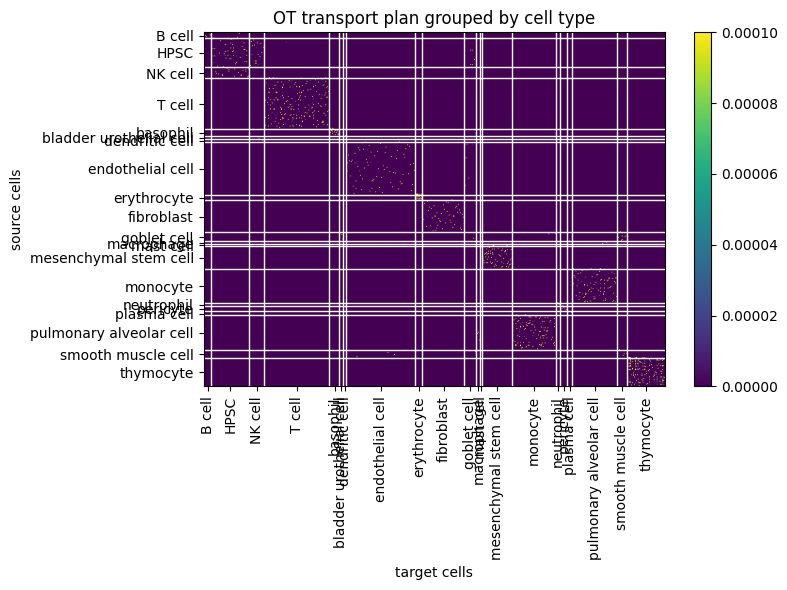

In [78]:
plot_ot_transport_by_celltype(gw_otdd_twohumans, human1_labels, human2_labels)

In [79]:
compute_mapping_acc(gw_otdd_twohumans, human1_labels, human2_labels)

0.659877800407332

In [80]:
monocyte_cst = human1[human1.obs['shared_cell_type']=='monocyte'].obs['cell_type'].value_counts().index.tolist()

In [81]:
human1_cst = cell_subtype_codes(human1, monocyte_cst)

In [82]:
human2_cst = cell_subtype_codes(human2, monocyte_cst)

In [83]:
sublabel_match_rate_from_gw(gw_otdd_twohumans, human1_labels, human2_labels, human1_cst, human2_cst)

0.0

In [85]:
regy_arr = [1000, 5000, 10000, 50000, 100000]
eps_arr = [0.001, 0.01, 0.1]
acc_arr = []
sublabel_acc_arr = []
for reg_y in regy_arr:
    for eps in eps_arr:
        otdd_dists1 = otdd_distance_matrix(label_dist_df1, human1_X, human1_labels, reg_y=reg_y)
        otdd_dists2 = otdd_distance_matrix(label_dist_df2, human2_X, human2_labels, reg_y=reg_y)
        gw_otdd_twohumans = run_gw_otdd(otdd_dists1, otdd_dists2, epsilon=eps)
        
        acc = compute_mapping_acc(gw_otdd_twohumans, human1_labels, human2_labels)
        sublabel_acc = sublabel_match_rate_from_gw(gw_otdd_twohumans, human1_labels, human2_labels, human1_cst, human2_cst)
        acc_arr.append(acc)
        sublabel_acc_arr.append(sublabel_acc)

        print(reg_y, eps, acc, sublabel_acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


1000 0.001 0.29124236252545826 0.0425531914893617


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


1000 0.01 0.5784114052953157 0.3617021276595745


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


...

100000 0.001 0.1975560081466395 0.0


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


100000 0.01 0.5498981670061099 0.0


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


100000 0.1 0.6293279022403259 0.0


In [86]:
reg_df = pd.DataFrame([regy_arr, eps_arr, acc_arr, sublabel_acc_arr]).T
reg_df.columns = ['reg_y', 'epsilon', 'accuracy', 'sublabel_accuracy']
reg_df.to_csv('data/otdd_regy_eps_accuracy_021126.csv')

Conclusion: OTDD still has symmetry issues. At least two major cell types always swapped.

### Removing pulmonary alveolar cells (in addition to generic monocytes)

In [15]:
num_cells = 250

In [16]:
human1, human2 =  match_cells_by_celltype_tissue(human_adatas[0], human_adatas[1], cell_number=num_cells)

In [17]:
human1 = human1[human1.obs['cell_type']!='monocyte']  # remove generic 'monocyte' cell type
human2 = human2[human2.obs['cell_type']!='monocyte']

In [18]:
human1 = human1[human1.obs['shared_cell_type']!='pulmonary alveolar cell']  # remove pulmonary alveolar cells
human2 = human2[human2.obs['shared_cell_type']!='pulmonary alveolar cell']

In [19]:
sc.tl.pca(human1, n_comps=50, svd_solver="arpack")
sc.tl.pca(human2, n_comps=50, svd_solver="arpack")

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [20]:
human1_X = human1.obsm['X_pca']
human2_X = human2.obsm['X_pca']

In [21]:
human1_labels = human1.obs['shared_cell_type'].tolist()
human2_labels = human2.obs['shared_cell_type'].tolist()

In [22]:
label_dist_df1 = pairwise_uot_w2_by_label(human1_X, human1_labels)

In [23]:
label_dist_df2 = pairwise_uot_w2_by_label(human2_X, human2_labels)

In [26]:
otdd_dists1 = otdd_distance_matrix(label_dist_df1, human1_X, human1_labels, reg_y=50000)

In [27]:
otdd_dists2 = otdd_distance_matrix(label_dist_df2, human2_X, human2_labels, reg_y=50000)

[[ 18.5624672   20.06937999  22.34666216 ... 135.82102928 129.96817719
  131.35695659]
 [ 20.06937999  18.5624672   21.47591481 ... 135.96420662 130.52577407
  131.89831328]
 [ 22.34666216  21.47591481  18.5624672  ... 136.25730767 130.91740526
  132.23990681]
 ...
 [135.82102928 135.96420662 136.25730767 ...  43.08619286  58.93798174
   61.93448414]
 [129.96817719 130.52577407 130.91740526 ...  58.93798174  43.08619286
   47.96601498]
 [131.35695659 131.89831328 132.23990681 ...  61.93448414  47.96601498
   43.08619286]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

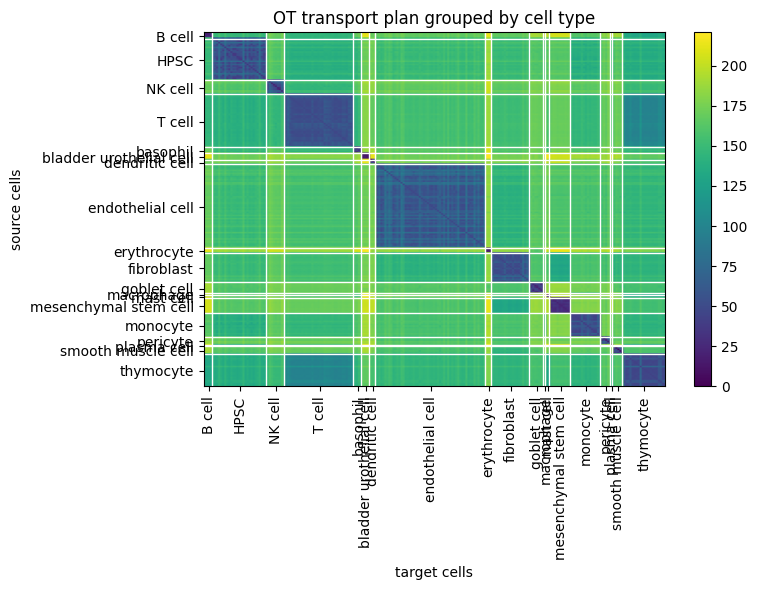

In [31]:
plot_ot_transport_by_celltype(otdd_dists1, human1_labels, human2_labels)

In [34]:
gw_otdd_twohumans = run_gw_otdd(otdd_dists1, otdd_dists2, epsilon=0.05)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


[[0.00032547 0.00134438 0.00133523 ... 0.         0.         0.        ]
 [0.00151382 0.00068373 0.00113181 ... 0.         0.         0.        ]
 [0.00249488 0.0004035  0.00078562 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

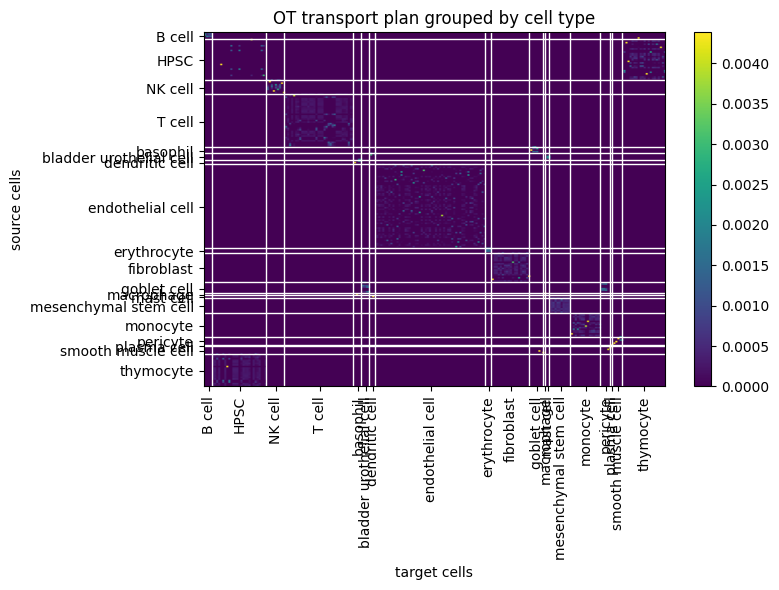

In [35]:
plot_ot_transport_by_celltype(gw_otdd_twohumans, human1_labels, human2_labels)

In [36]:
compute_mapping_acc(gw_otdd_twohumans, human1_labels, human2_labels)

0.6842105263157895

In [37]:
monocyte_cst = human1[human1.obs['shared_cell_type']=='monocyte'].obs['cell_type'].value_counts().index.tolist()

In [40]:
human1_cst = cell_subtype_codes(human1, monocyte_cst)

In [41]:
human2_cst = cell_subtype_codes(human2, monocyte_cst)

In [42]:
sublabel_match_rate_from_gw(gw_otdd_twohumans, human1_labels, human2_labels, human1_cst, human2_cst)

0.2